# Hierarchisch Clusteren

### Eenvoudige Data Analyse

In [23]:
import pandas as pd

# Pas het pad aan naar de shopping-data.csv file 
customer_data = pd.read_csv('../data/shopping-data.csv')

In [2]:
customer_data.shape

(200, 5)

In [3]:
# geef de kolommen van de dataset weer
customer_data.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

<Axes: xlabel='Spending Score (1-100)', ylabel='Count'>

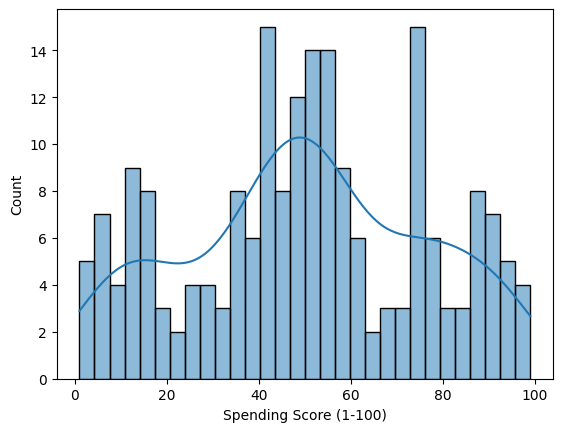

In [5]:
# maak een histogram van de "Spending Score"
import seaborn as sns

sns.histplot(data=customer_data,x='Spending Score (1-100)', bins=30, kde=True)

In [6]:
# Geef de statistische kenmerken van de dataset weer
customer_data.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

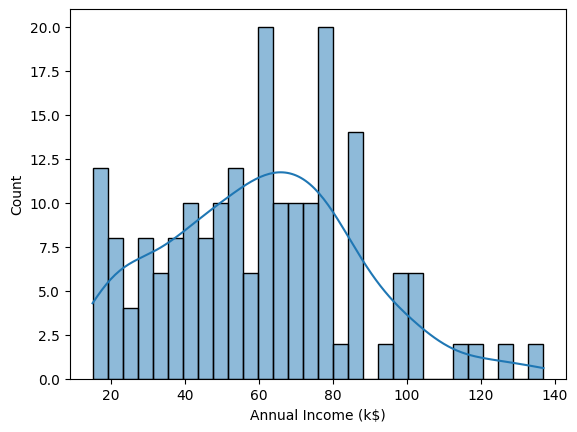

In [10]:
# Maak een histogram van het inkomen
sns.histplot(data=customer_data,x='Annual Income (k$)', bins=30, kde=True)

In [13]:
# Ga na of er ontbrekende gegevens in de dataset zitten
customer_data.isnull().sum().sum()

np.int64(0)

In [14]:
# Geef de eerste rijen van de dataset weer...
customer_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [16]:
# Bekijk de unieke waarden voor 'Genre'
customer_data.Genre.unique()

array(['Male', 'Female'], dtype=object)

In [17]:
# Ga na wat de percentages horend bij man en vrouw zijn
customer_data.Genre.value_counts(normalize=True)

Genre
Female    0.56
Male      0.44
Name: proportion, dtype: float64

### Dummy Encoding en Feature Engineering

In [24]:
# Voeg een nieuwe kolom 'Age Groups' toe aan customer_data.  Deze kolom moet onderverdeeld zijn
# in discrete intervallen ('bins').  Je kan hiervoor pd.cut() gebruiken.

intervals = [15, 20, 30, 40, 50, 60, 70]

customer_data["Age Groups"] = pd.cut(customer_data["Age"], bins=intervals)

# Geef de 'Age Groups' kolom weer zodat je kan zien hoe de gegevens zijn ingedeeld
customer_data["Age Groups"]

0      (15, 20]
1      (20, 30]
2      (15, 20]
3      (20, 30]
4      (30, 40]
         ...   
195    (30, 40]
196    (40, 50]
197    (30, 40]
198    (30, 40]
199    (20, 30]
Name: Age Groups, Length: 200, dtype: category
Categories (6, interval[int64, right]): [(15, 20] < (20, 30] < (30, 40] < (40, 50] < (50, 60] < (60, 70]]

In [29]:
# Geef het aantal personen per leeftijdsgroep weer
customer_data.groupby('Age Groups', observed=False)['CustomerID'].count()

Age Groups
(15, 20]    17
(20, 30]    45
(30, 40]    60
(40, 50]    38
(50, 60]    23
(60, 70]    17
Name: CustomerID, dtype: int64

In [30]:
# Voer dummy Encoding uit
customer_data_enc = pd.get_dummies(customer_data)
# Geef het dataframe na dummy encoding weer
customer_data_enc

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),Genre_Female,Genre_Male,"Age Groups_(15, 20]","Age Groups_(20, 30]","Age Groups_(30, 40]","Age Groups_(40, 50]","Age Groups_(50, 60]","Age Groups_(60, 70]"
0,1,19,15,39,False,True,True,False,False,False,False,False
1,2,21,15,81,False,True,False,True,False,False,False,False
2,3,20,16,6,True,False,True,False,False,False,False,False
3,4,23,16,77,True,False,False,True,False,False,False,False
4,5,31,17,40,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
195,196,35,120,79,True,False,False,False,True,False,False,False
196,197,45,126,28,True,False,False,False,False,True,False,False
197,198,32,126,74,False,True,False,False,True,False,False,False
198,199,32,137,18,False,True,False,False,True,False,False,False


### Plot de data

In [36]:
# Verwijder de CustomerID kolom van de dataset 
customer_data = customer_data.drop("CustomerID", axis=1)

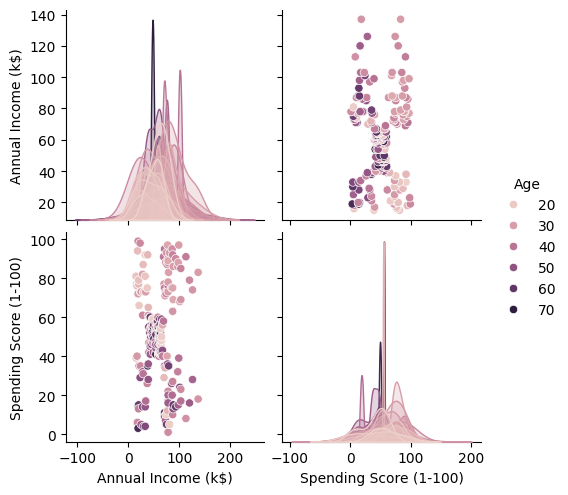

In [51]:
# maak een pairplot van de data
sns.pairplot(data=customer_data, hue="Age");

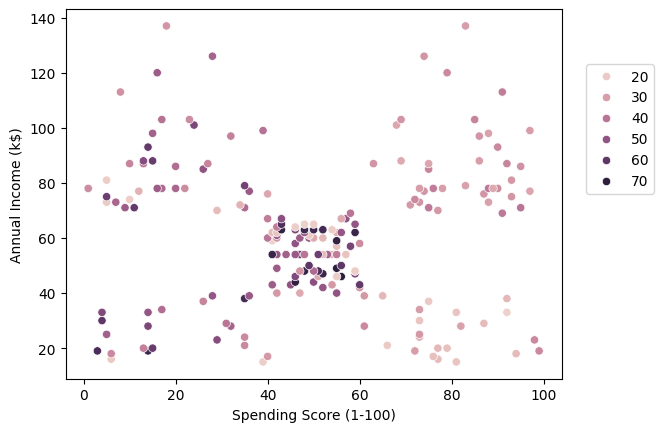

In [50]:
# Maak een scatterplot van de data: Spending Score vs Annual Income
import matplotlib.pyplot as plt

sns.scatterplot(data=customer_data, x='Spending Score (1-100)', y='Annual Income (k$)', hue='Age')
plt.legend(loc=(1.05, 0.5))
plt.show()


### Visualiseer de Hiërarchische Structuur met een Dendrogram

In [53]:
customer_data_enc

,Age,Annual Income (k$),Spending Score (1-100),Genre_Female,Genre_Male,"Age Groups_(15, 20]","Age Groups_(20, 30]","Age Groups_(30, 40]","Age Groups_(40, 50]","Age Groups_(50, 60]","Age Groups_(60, 70]"
0,19,15,39,False,True,True,False,False,False,False,False
1,21,15,81,False,True,False,True,False,False,False,False
2,20,16,6,True,False,True,False,False,False,False,False
3,23,16,77,True,False,False,True,False,False,False,False
4,31,17,40,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
195,35,120,79,True,False,False,False,True,False,False,False
196,45,126,28,True,False,False,False,False,True,False,False
197,32,126,74,False,True,False,False,True,False,False,False
198,32,137,18,False,True,False,False,True,False,False,False


In [54]:
import scipy.cluster.hierarchy as shc

# Selecteer Annual Income en Spending Scores door hun index
selected_data = customer_data_enc.iloc[:, 1:3]
# Cluster met de ward methode
clusters = shc.linkage(selected_data, 
            method='ward', 
            metric="euclidean")

#### Visualiseer het Dendrogram en kies een aantal clusters.  Visualiseer de "cutoff" lijn.

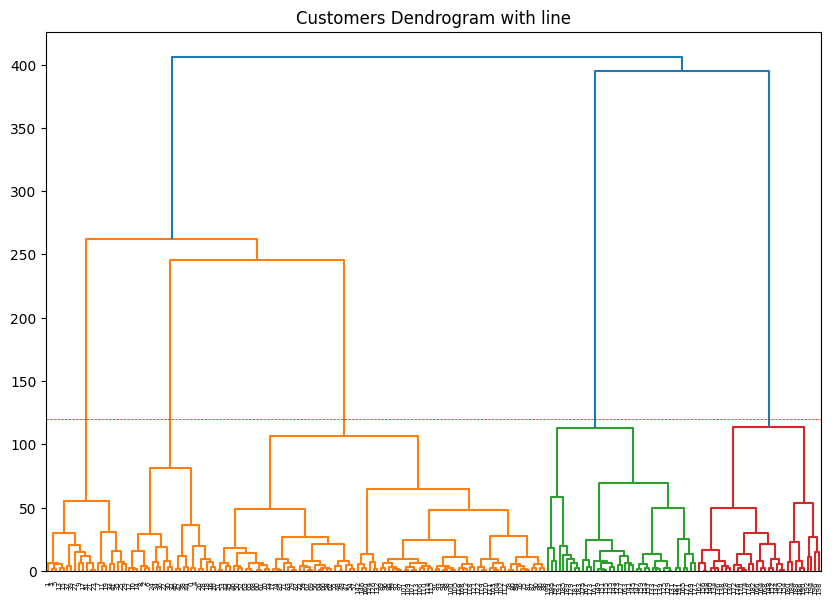

In [63]:
plt.figure(figsize=(10, 7))
plt.title("Customers Dendrogram with line")
shc.dendrogram(clusters)
plt.axhline(y = 120, color = 'r', linestyle = '--', lw=0.5);

### Implementeer nu Agglomeratief Hierarchisch Clusteren met je aantal gekozen clusters
#### Gebruik de Originele Data

In [64]:
from sklearn.cluster import AgglomerativeClustering

clustering_model = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
clustering_model.fit(selected_data)
clustering_model.labels_

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 1,
       4, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 2,
       1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 1, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 2])

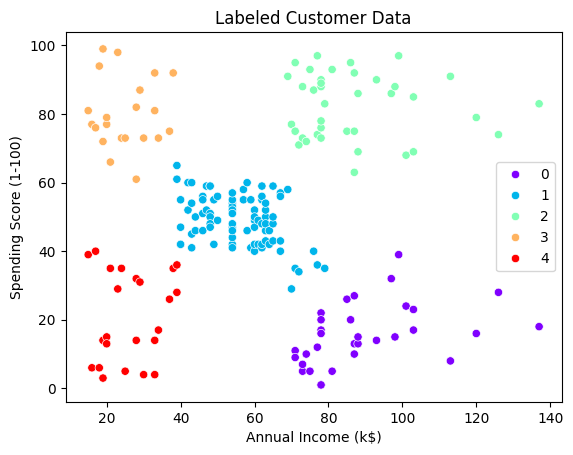

In [65]:
# Visualiseer nu de clusters middels een scatterplot
data_labels = clustering_model.labels_
sns.scatterplot(x='Annual Income (k$)', 
                y='Spending Score (1-100)', 
                data=customer_data,  # selected_data, 
                hue=data_labels,
                palette="rainbow").set_title('Labeled Customer Data');

# Optioneel:

- Maak de linkage matrix op.  Gebruik de truncation methodes om het aantal levels te beperken.  
- Wat is de maximale theoretische afstand tussen 2 punten in de dataset? En in praktijk?
- Maak een model op basis van een door jou gekozen distance treshold
- Gebruik de elbow methode voor hiërarchisch clusteren.  Wat is een goed aantal clusters volgens deze methode?

In [67]:
linkage_matrix = shc.linkage(clustering_model.children_)
distances = linkage_matrix[:, 2]

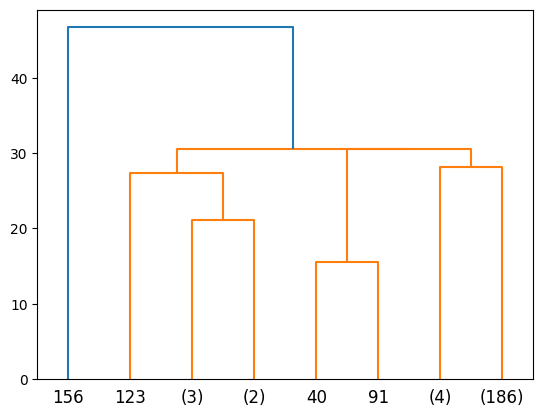

In [71]:
shc.dendrogram(linkage_matrix, truncate_mode='level', p=3);

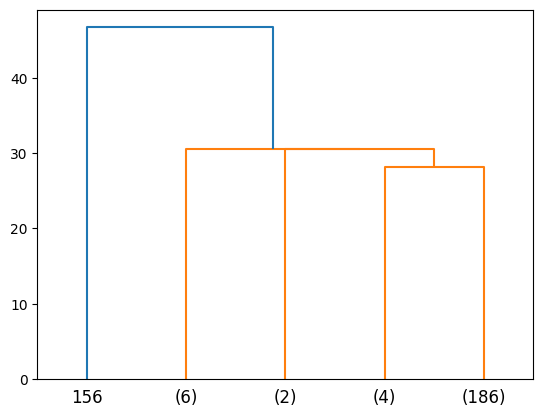

In [73]:
shc.dendrogram(linkage_matrix, truncate_mode='lastp', p=5);

Text(0, 0.5, 'Afstand')

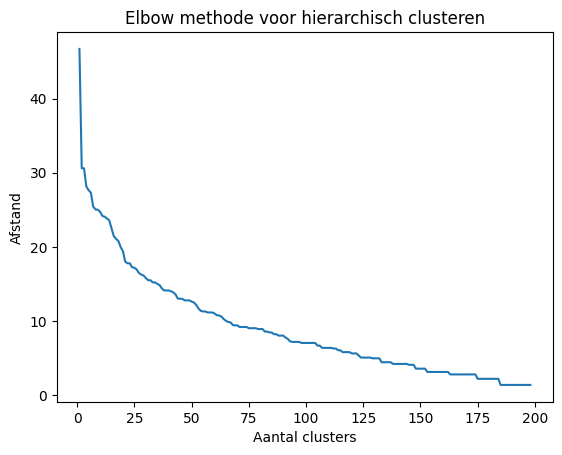

In [68]:
plt.plot(range(1, len(distances)+1), distances[::-1])
plt.title('Elbow methode voor hierarchisch clusteren')
plt.xlabel('Aantal clusters')
plt.ylabel('Afstand')
